In [1]:
from pathlib import Path
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

REPO_DIR = Path("/home/ganchao/Desktop/traj_decoding/trajectory-decoding")

print("REPO_DIR:", REPO_DIR)
print("exists:", REPO_DIR.exists())

REPO_DIR: /home/ganchao/Desktop/traj_decoding/trajectory-decoding
exists: True


In [2]:
paths = {
    "data dir": REPO_DIR / "data",
    "checkpoints dir": REPO_DIR / "checkpoints",
    "autoencoder": REPO_DIR / "checkpoints" / "autoencoder.pt",
    "encoder": REPO_DIR / "checkpoints" / "encoder.pt",
    "reconstructions": REPO_DIR / "reconstructions.png",
    "embeddings PCA": REPO_DIR / "embeddings_pca.png",
}

for name, path in paths.items():
    print(f"{name:16s}", path.exists(), path)

data dir         True /home/ganchao/Desktop/traj_decoding/trajectory-decoding/data
checkpoints dir  True /home/ganchao/Desktop/traj_decoding/trajectory-decoding/checkpoints
autoencoder      True /home/ganchao/Desktop/traj_decoding/trajectory-decoding/checkpoints/autoencoder.pt
encoder          True /home/ganchao/Desktop/traj_decoding/trajectory-decoding/checkpoints/encoder.pt
reconstructions  True /home/ganchao/Desktop/traj_decoding/trajectory-decoding/reconstructions.png
embeddings PCA   True /home/ganchao/Desktop/traj_decoding/trajectory-decoding/embeddings_pca.png


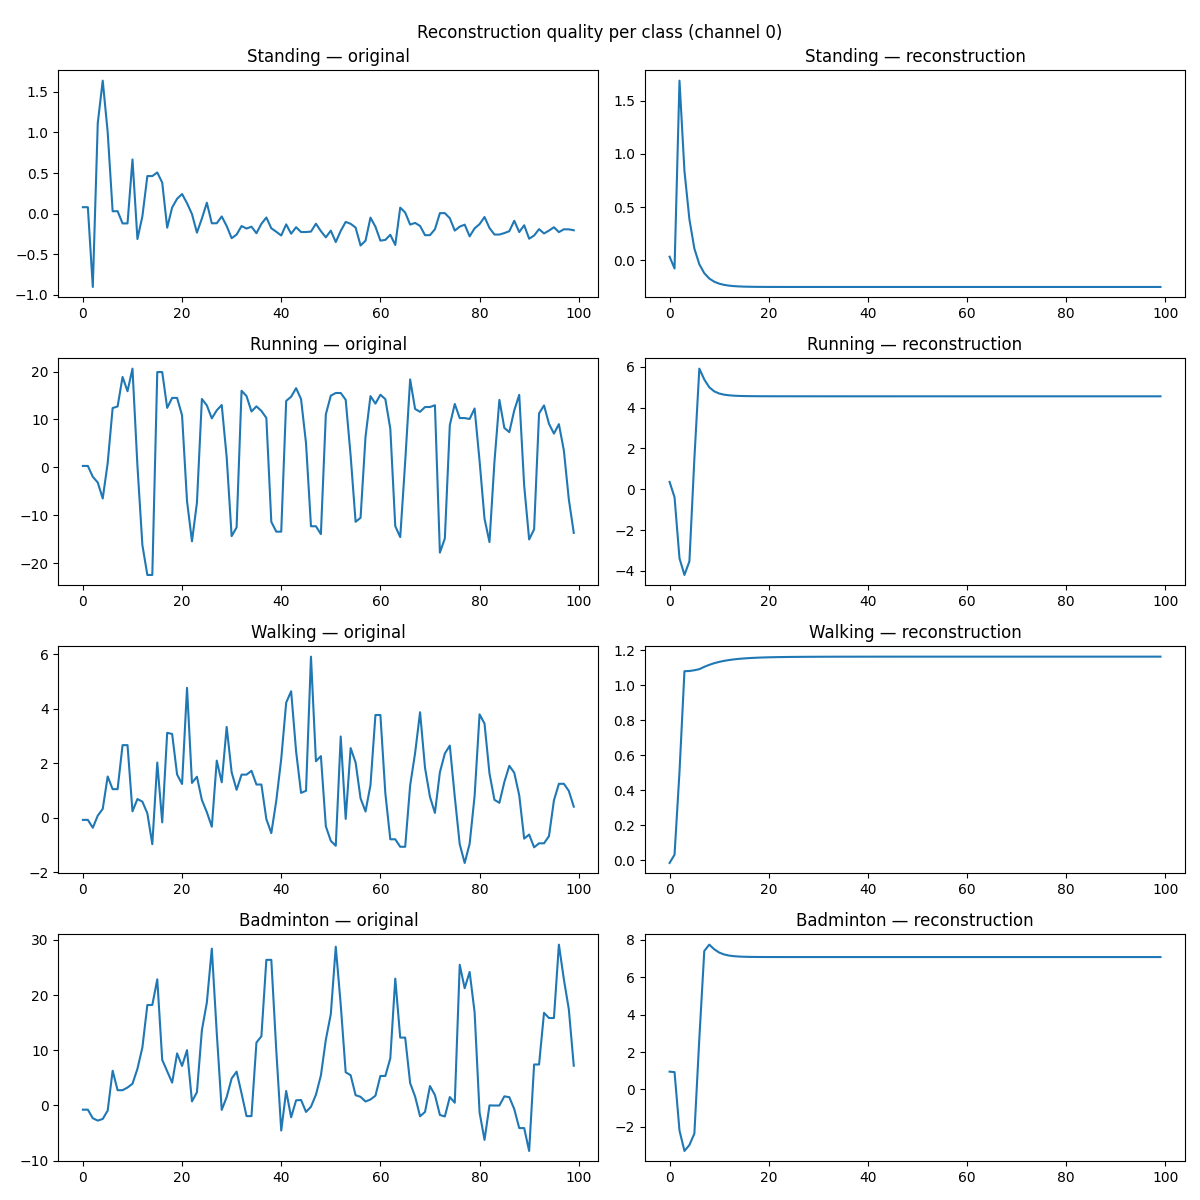

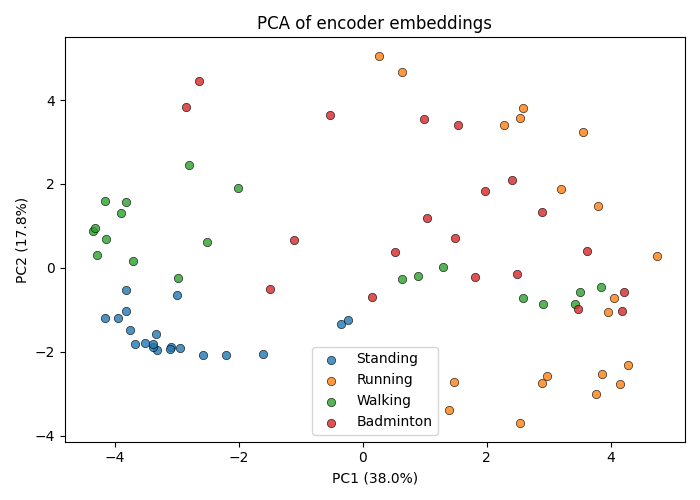

In [3]:
display(Image(filename=str(REPO_DIR / "reconstructions.png")))
display(Image(filename=str(REPO_DIR / "embeddings_pca.png")))

In [4]:
CLASSES = ["standing", "running", "walking", "badminton"]
CLASS_TO_IDX = {c.lower(): i for i, c in enumerate(CLASSES)}

def parse_ts_text(text):
    X = []
    y = []
    in_data = False

    for line in text.splitlines():
        line = line.strip()

        if len(line) == 0:
            continue

        if line.lower().startswith("@data"):
            in_data = True
            continue

        if line.startswith("@"):
            continue

        if not in_data:
            continue

        parts = line.split(":")
        label = parts[-1].strip().lower()
        dims = parts[:-1]

        arr = []
        for d in dims:
            vals = [float(v) for v in d.split(",") if v != ""]
            arr.append(vals)

        arr = np.asarray(arr, dtype=np.float32).T

        X.append(arr)
        y.append(CLASS_TO_IDX[label])

    return np.stack(X), np.asarray(y)

In [5]:
def find_ts_files(repo_dir):
    candidates = list((repo_dir / "data").rglob("*TRAIN.ts")) + list((repo_dir / "data").rglob("*_TRAIN.ts"))

    if len(candidates) > 0:
        train_path = candidates[0]
        test_path = Path(str(train_path).replace("TRAIN.ts", "TEST.ts"))

        with open(train_path, "r") as f:
            train_text = f.read()
        with open(test_path, "r") as f:
            test_text = f.read()

        return train_text, test_text

    zip_candidates = list((repo_dir / "data").rglob("*.zip"))

    for zip_path in zip_candidates:
        with zipfile.ZipFile(zip_path) as zf:
            names = zf.namelist()
            train_names = [n for n in names if n.endswith("TRAIN.ts") or n.endswith("_TRAIN.ts")]
            test_names = [n for n in names if n.endswith("TEST.ts") or n.endswith("_TEST.ts")]

            if len(train_names) > 0 and len(test_names) > 0:
                train_text = zf.read(train_names[0]).decode("utf-8")
                test_text = zf.read(test_names[0]).decode("utf-8")
                return train_text, test_text

    raise FileNotFoundError("Cannot find BasicMotions TRAIN/TEST .ts files.")

train_text, test_text = find_ts_files(REPO_DIR)

X_train, y_train = parse_ts_text(train_text)
X_test, y_test = parse_ts_text(test_text)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (40, 100, 6)
y_train: (40,)
X_test: (40, 100, 6)
y_test: (40,)


In [6]:
for k, name in enumerate(CLASSES):
    print(name)
    print("  train:", np.sum(y_train == k))
    print("  test :", np.sum(y_test == k))

standing
  train: 10
  test : 10
running
  train: 10
  test : 10
walking
  train: 10
  test : 10
badminton
  train: 10
  test : 10


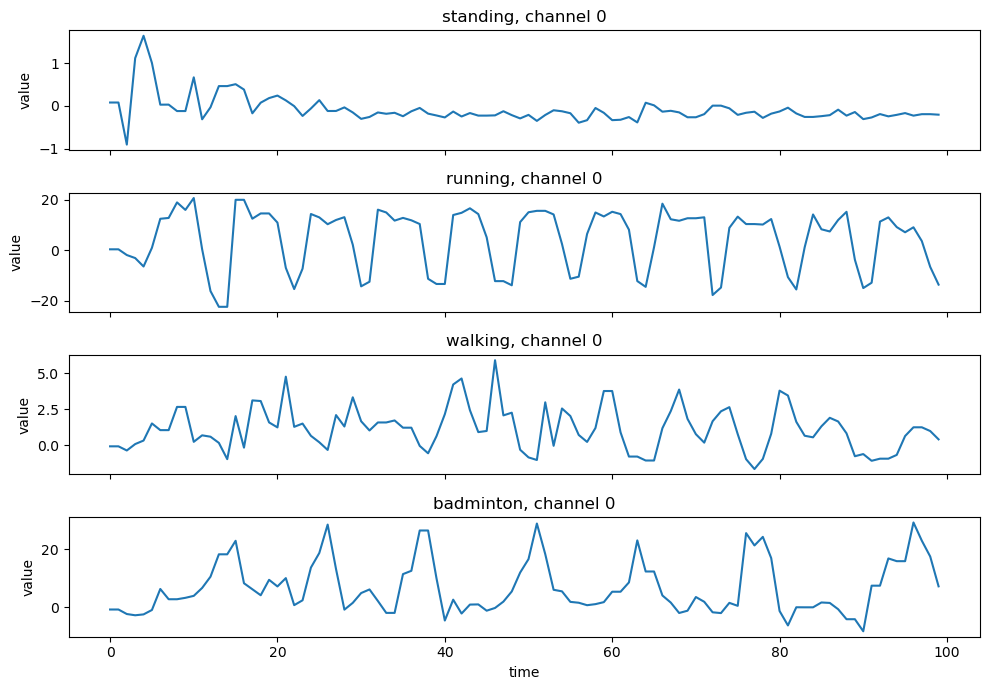

In [7]:
fig, axes = plt.subplots(len(CLASSES), 1, figsize=(10, 7), sharex=True)

for k, name in enumerate(CLASSES):
    idx = np.where(y_train == k)[0][0]
    axes[k].plot(X_train[idx, :, 0])
    axes[k].set_title(f"{name}, channel 0")
    axes[k].set_ylabel("value")

axes[-1].set_xlabel("time")
plt.tight_layout()
plt.show()

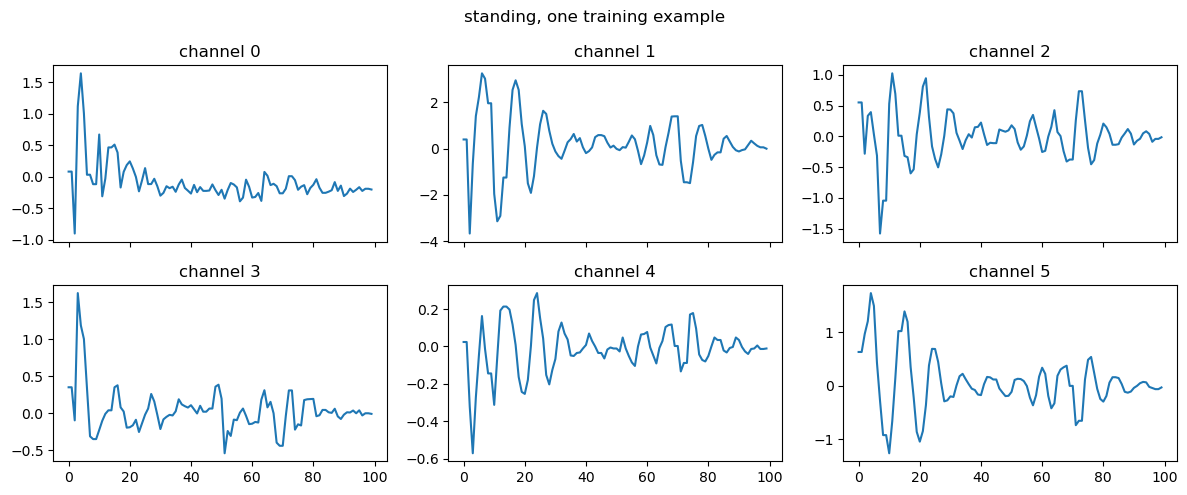

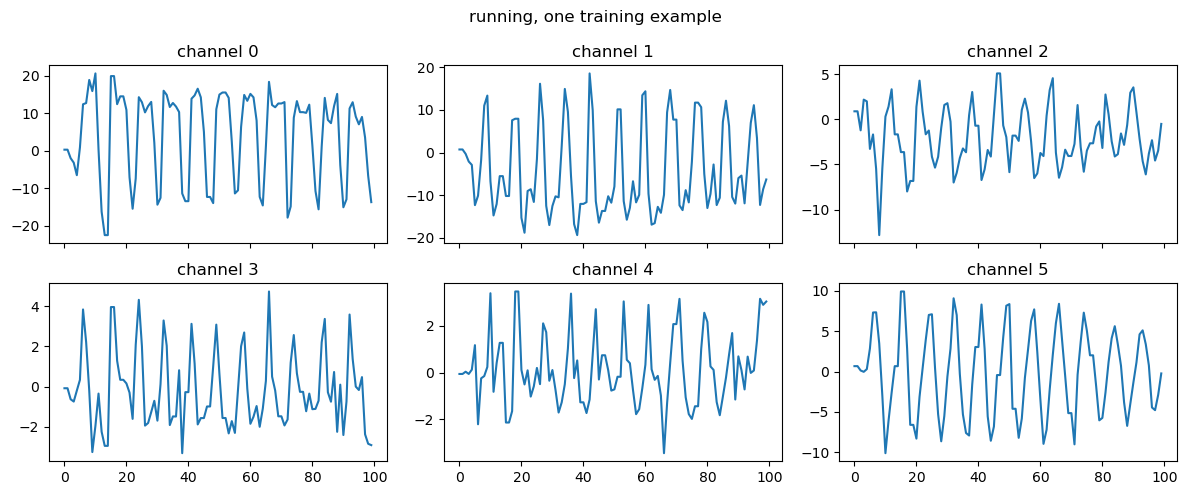

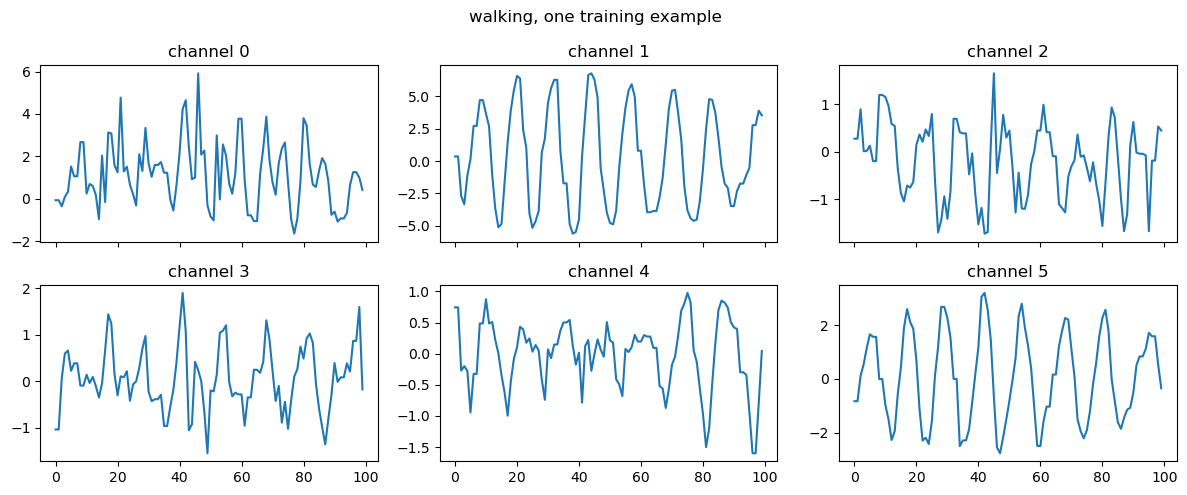

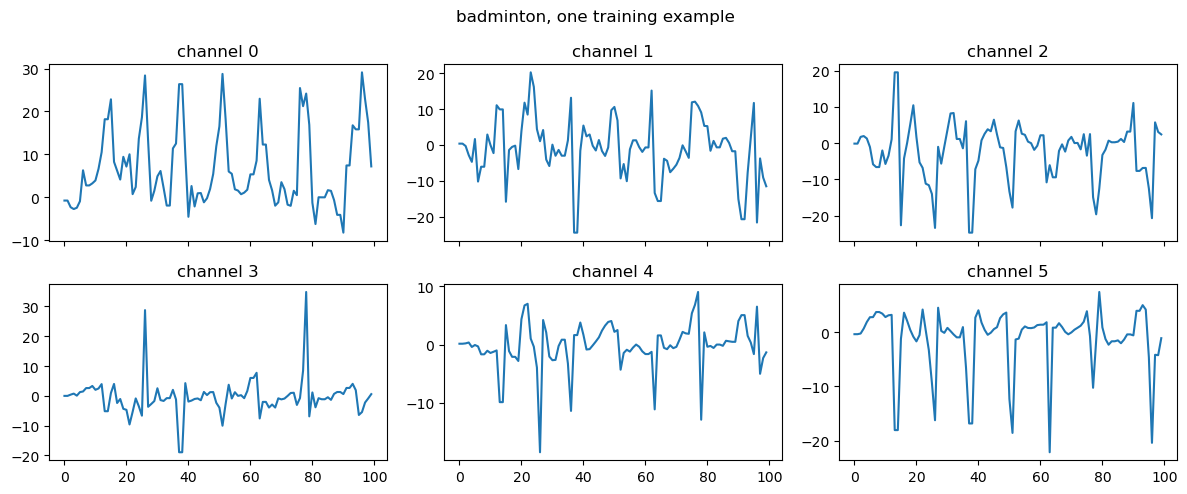

In [8]:
for k, name in enumerate(CLASSES):
    idx = np.where(y_train == k)[0][0]

    fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharex=True)
    fig.suptitle(f"{name}, one training example")

    for ch in range(X_train.shape[-1]):
        ax = axes.flat[ch]
        ax.plot(X_train[idx, :, ch])
        ax.set_title(f"channel {ch}")

    plt.tight_layout()
    plt.show()

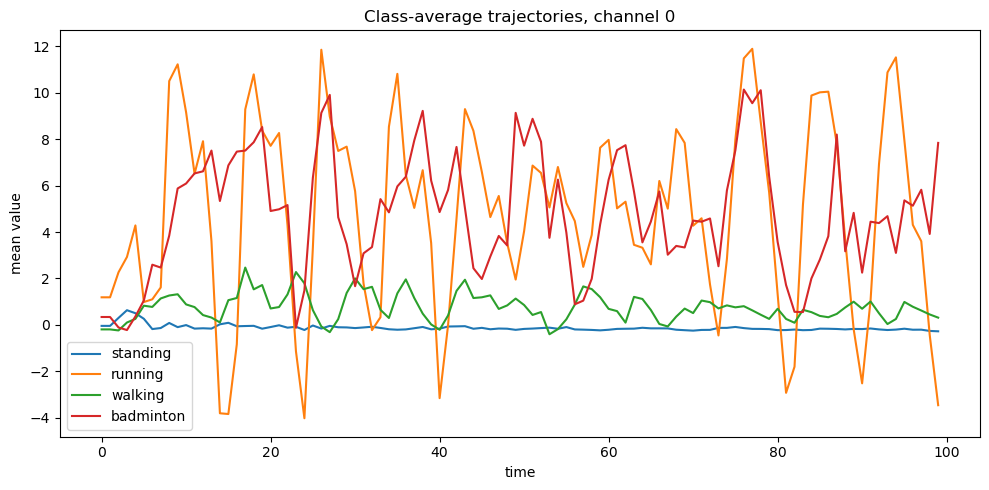

In [9]:
plt.figure(figsize=(10, 5))

for k, name in enumerate(CLASSES):
    mean_trace = X_train[y_train == k, :, 0].mean(axis=0)
    plt.plot(mean_trace, label=name)

plt.xlabel("time")
plt.ylabel("mean value")
plt.title("Class-average trajectories, channel 0")
plt.legend()
plt.tight_layout()
plt.show()

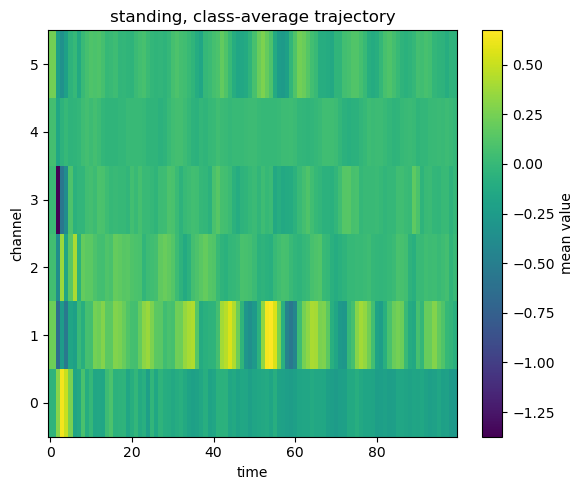

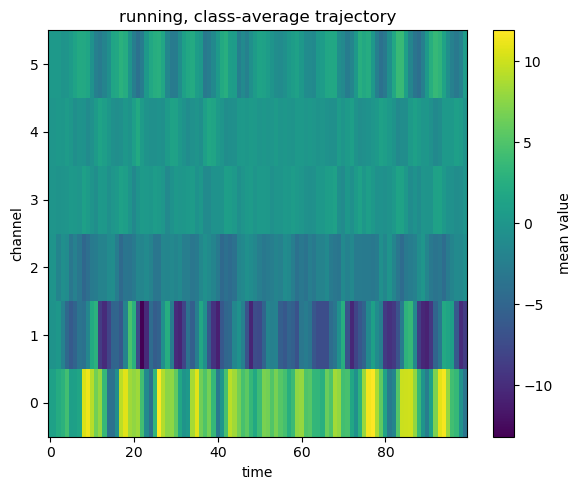

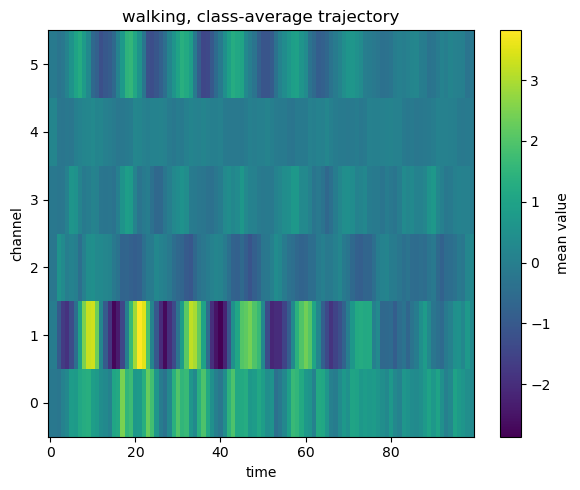

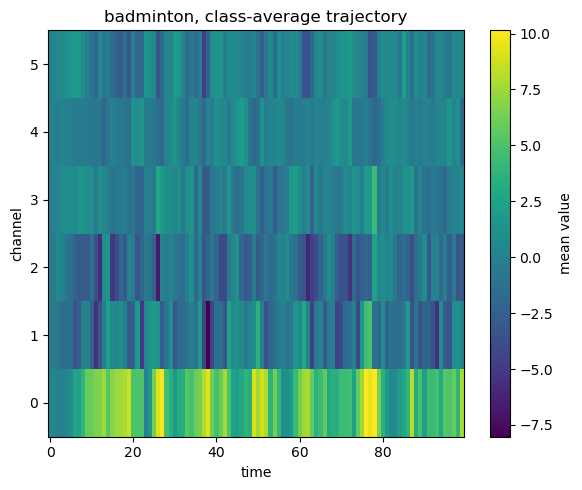

In [10]:
for k, name in enumerate(CLASSES):
    mean_tc = X_train[y_train == k].mean(axis=0)

    plt.figure(figsize=(6, 5))
    plt.imshow(mean_tc.T, aspect="auto", origin="lower")
    plt.colorbar(label="mean value")
    plt.xlabel("time")
    plt.ylabel("channel")
    plt.title(f"{name}, class-average trajectory")
    plt.tight_layout()
    plt.show()